In [2]:
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing

In [ ]:
"""
Replica helpers for the two-hidden-layer MLP (Result 3, Sec. II B)
specialised to Gaussian readouts P_v = N(0,1) and gamma_1 = gamma_2 = 0.5.

Both hidden layers share the SAME activation function sigma, with Hermite
coefficients [mu_0, mu_1, mu_2, ...] stored in a single `coeff` array, and
mu_0 = mu_2 = 0  (hypothesis H2 of the paper).  Both layers therefore share
the same g function:

    g_3(q) = sum_{ell >= 3}  mu_ell^2 / ell!  * q^ell       (eq. B6)

and the single-layer full covariance function

    g_1(q) = mu_1^2 * q + g_3(q),

so that K_d = g_1(g_1(1))  and  K^* = f(Q_1, Q_2, Q_{2:1})  (see eq. C20).

KEY APPROXIMATION — Gaussian channel for the Q_{2:1} / iota_v terms:
----------------------------------------------------------------------
In the exact theory (Result 3 / App. C1), the product overlap Q_{2:1}(v)
requires the RECTANGULAR MMSE and iota_v loaded from a CSV file, because
the relevant matrix denoising problem (eq. C27) involves a non-trivial
singular-value distribution.

For Gaussian readouts P_v = N(0,1) we discretise v into bins, each with
small probability weight P_v(v) << 1.  Numerically, the rectangular iota_v
with aspect ratio eta = P_v(v)*gamma_2 << 1 is observed to converge to the
SCALAR GAUSSIAN CHANNEL iota:

    iota_v^{Gauss}(x) = log(1 + x * (1 - target_v))

where  target_v = E_{v^(2) ~ P_s2}[Q_2(v, v^(2)) * Q_1(v^(2))].

This corresponds to the limit where each readout-bin contributes as an
independent Gaussian channel with noise variance proportional to
1 - target_v.  In this approximation:

  (i)  The moment-matching condition (C30)  mmse_v(tau_v) = 1 - target_v
       is satisfied by the Gaussian MMSE  mmse_gauss(tau_v) = (1-target_v)
       / (1 + tau_v*(1-target_v)).  Solving for tau_v gives tau_v = 0,
       so the moment-matching condition is trivially satisfied at tau_v = 0
       and no CSV/spline inversion is needed.

  (ii) The Q_{2:1}(v) update (last-but-one eq. of C31) becomes:
           Q_{2:1}(v) = 1 - mmse_v^Gauss(r_W_12(v))
                      = r_W_12(v) * (1-target_v) / (1 + r_W_12(v)*(1-target_v))

  (iii)The iota_v contributions to the conjugate OPs Q-hat_1 and Q-hat_2
       (the "termC" and "second part" terms in their update equations) are
       derived from differentiating  -log(1 + r_W_12*(1-target_v))
       directly with respect to the OPs, giving weight
           weight_R(v) = P_v(v) * r_W_12(v) / denom2(v)
       where  denom2(v) = 1 + r_W_12(v) * (1-target_v).

  (iv) The iota_v term in f^(2)_RS (Result 3) becomes
           -(iota_v(r_W_12) - iota_v(0)) = -log(1 + r_W_12*(1-target_v))
       (with the normalisation convention used here absorbing the 1/2 from
       the I-MMSE relation).
"""

import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import brentq


# ---------------------------------------------------------------------------
# Inner-weight prior selection
# ---------------------------------------------------------------------------
#opt = 'rad'
opt = 'gauss'


# ===========================================================================
# Gauss-Hermite quadrature (for Rademacher prior)
# ===========================================================================

_GH_ORDER = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)     # nodes x_i, weights w_i for e^{-x^2}
_GH_scale    = 1.0 / np.sqrt(np.pi)     # normalisation: int e^{-x^2} dx = sqrt(pi)

def _gauss_hermite_expectation(f_vals_at_scaled_nodes):
    """
    Approximate  E_z[f(z)] = (1/sqrt(pi)) * sum_i w_i * f(sqrt(2)*x_i)
    for z ~ N(0,1), given f evaluated at the scaled GH nodes sqrt(2)*x_i.
    """
    return np.tensordot(_GH_w * _GH_scale, f_vals_at_scaled_nodes, axes=(0, 0))


# ===========================================================================
# Scalar-channel functions: psi_w and psi (= psi_{P_W})
# ===========================================================================

def psi_w_vec(l_arr, opt='rad'):
    """
    Evaluate the posterior-mean channel function

        psi_w(l) = E_{w^0, xi}[ w^0 <w>_l ]
                 = E_z[ tanh(sqrt(l)*z + l) ],   z ~ N(0,1),

    entering the layer-wise saddle-point equations (C31):
        Q_l(v) = psi_w(Q-hat_l(v))   for l = 1, 2.

    Closed form l/(1+l) for Gaussian prior; Gauss-Hermite quadrature
    for Rademacher prior.
    """
    l = np.asarray(l_arr, dtype=float)
    if opt == 'gauss':
        return l / (1.0 + l)

    # Rademacher: numerical GH quadrature
    scalar_input = (l.ndim == 0)
    l = l.ravel() if not scalar_input else l.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                               # (N,)
    sqrt_l  = np.sqrt(np.maximum(l, 0.0))                        # (L,)
    arg     = z_nodes[:, None] * sqrt_l[None, :] + l[None, :]    # (N, L)
    vals    = np.tanh(arg)                                        # (N, L)
    exps    = _gauss_hermite_expectation(vals)                    # (L,)
    return exps.reshape(()) if scalar_input else exps


def psi_vec(g_arr, opt='rad'):
    """
    Evaluate the scalar-channel free entropy psi_{P_W}(x) (Sec. II):

        psi(g) = E_z[ log cosh(sqrt(g)*z + g) ] - g/2,   z ~ N(0,1).

    Appears in f^(2)_RS (Result 3) through the psi_{P_Wl}(Q-hat_l(v)) terms.

    Closed form g/2 - log(1+g)/2 for Gaussian prior; Gauss-Hermite quadrature
    for Rademacher prior.
    """
    g = np.asarray(g_arr, dtype=float)
    if opt == 'gauss':
        return 0.5 * g - 0.5 * np.log(1.0 + g)

    # Rademacher: numerical GH quadrature
    scalar_input = (g.ndim == 0)
    g = g.ravel() if not scalar_input else g.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                               # (N,)
    sqrt_g  = np.sqrt(np.maximum(g, 0.0))                        # (L,)
    arg     = z_nodes[:, None] * sqrt_g[None, :] + g[None, :]    # (N, L)
    vals    = np.log(np.cosh(arg))                                # (N, L)
    exps    = _gauss_hermite_expectation(vals)                    # (L,)
    out     = -0.5 * g + exps
    return out.reshape(()) if scalar_input else out


def m_inv_vec(q, opt='rad'):
    """
    Invert psi_w: find Q-hat such that psi_w(Q-hat) = q.

    Solves the first equation of (C31) for the conjugate OP given the primal:
        Q_l(v) = psi_w(Q-hat_l(v))   =>   Q-hat_l(v) = psi_w^{-1}(Q_l(v)).

    Closed form q/(1-q) for Gaussian prior; bracket-search + Brent for
    Rademacher prior.
    """
    q_arr = np.atleast_1d(q).astype(float)
    out   = np.empty_like(q_arr)

    if opt == 'gauss':
        out = q_arr / (1.0 - q_arr)
        return out if q_arr.shape != () else out.item()

    # Rademacher: bracket-doubling + Brent's method
    for idx, qv in enumerate(q_arr):
        if qv <= 0:
            out[idx] = 0.0
            continue
        lo, hi = 0.0, 1.0
        while psi_w_vec(hi, opt=opt) < qv:
            hi *= 2.0
            if hi > 1e6:
                break
        f    = lambda x: psi_w_vec(x, opt=opt) - qv
        out[idx] = brentq(f, lo, hi, maxiter=100, xtol=1e-12)

    return out if q_arr.shape != () else out.item()


# ===========================================================================
# Expectation helpers over the readout and effective-readout distributions
# ===========================================================================

def EE_s(arr, P_v):
    """
    Compute  E_{v ~ P_v}[arr(v)] = sum_k P_v[k] * arr[k].
    Used for scalar expectations over P_v or P_s2.
    """
    return np.tensordot(np.asarray(P_v), arr, axes=(0, 0))


def EE_s_g(q_W, v, P_v, g):
    """
    Compute  E_{v ~ P_v}[ v^2 * g(Q(v)) ] = sum_k P_v[k] * v[k]^2 * g(Q[k]).

    Enters K* (eq. C20) when g = g_3 (higher-order covariance term), e.g.
        E_{v^(2)}[(v^(2))^2 g_3(Q_1(v^(2)))]   for the (mu_1^(2))^2 term,
        E_v[v^2 g_3(inner_v)]                   for the outer g^(2) term.
    """
    return float(np.dot(np.asarray(P_v), (np.asarray(v)**2) * g(np.asarray(q_W))))


def EE_s_qW2(q_W, v, P_v):
    """
    Compute  E_{v ~ P_v}[ v^2 * Q(v)^2 ] = sum_k P_v[k] * v[k]^2 * Q[k]^2.
    """
    return float(np.dot(np.asarray(P_v), (np.asarray(v)**2) * (np.asarray(q_W)**2)))


def EE_FSB(mat, arr, P_v):
    """
    Compute the P_v-weighted matrix-vector product
        [EE_FSB(M, arr, P_v)]_i = sum_j M[i,j] * P_v[j] * arr[j]
                                 = E_{j ~ P_v}[ M[i,j] * arr[j] ],

    where M has shape (I, J) and arr, P_v have shape (J,).

    Used to marginalise the matrix OP Q_2(v, v^(2)) over one of its indices:

      target_v = EE_FSB(q_W_2, q_W_1, P_s2)
               = E_{v^(2) ~ P_s2}[ Q_2(v, v^(2)) * Q_1(v^(2)) ],  shape (V,)

      EE_FSB_val = EE_FSB(q_W_2, g_3(q_W_1), P_s2)
               = E_{v^(2) ~ P_s2}[ Q_2(v, v^(2)) * g_3(Q_1(v^(2))) ],  shape (V,)

    both appearing in K* (eq. C20) and the saddle-point equations (C31).
    """
    mat  = np.asarray(mat)
    arr  = np.asarray(arr)
    P_v  = np.asarray(P_v)
    return mat.dot(P_v * arr)


# ===========================================================================
# RS saddle-point solver
# ===========================================================================

def mmse_qW_NSB_FSB_fast(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_3, g_3_prime,
    v, P_v, s2, P_s2,
    d, coeff, alpha, gamma_1, gamma_2, delta,
    max_iter=1000, tol=1e-8, damp=0.1,
    opt='gauss'
):
    """
    Fixed-point solver for the RS saddle-point equations (C31) of the L=2 MLP
    with Gaussian readouts P_v = N(0,1), both layers sharing the same
    activation (single `coeff` array), and the GAUSSIAN CHANNEL APPROXIMATION
    for the rectangular iota_v (see module docstring).

    The three RS order parameters tracked are:

      q_W_1[s]    = Q_1(v^(2))    (shape (S,)):
          First-layer teacher-student overlap, labelled by the effective
          readout v^(2) discretised over s2 with weights P_s2.
          v^(2) ~ N(0,1) by CLT (Sec. II B).

      q_W_2[v,s]  = Q_2(v, v^(2)) (shape (V, S)):
          Second-layer overlap, labelled by the actual readout v (row) and
          effective readout v^(2) (column).  Captures inhomogeneity along
          both rows and columns of W^(2) (Fig. 16 in the paper).

      q_W_12[v]   = Q_{2:1}(v)    (shape (V,)):
          Product-matrix overlap for W^(2:1) = W^(2)W^(1)/sqrt(k_1).
          Possibly non-zero even before layer specialisation.

    The corresponding conjugate OPs are:
      r_W_1[s]    = Q-hat_1(v^(2))   (shape (S,))
      r_W_2[v,s]  = Q-hat_2(v, v^(2)) (shape (V, S))
      r_W_12[v]   = Q-hat_{2:1}(v)    (shape (V,))

    The post-activation covariance (eq. C20) with both layers identical reads:
        K_d = g_1(g_1(1))      (diagonal,  where g_1(q) = c1*q + g_3(q))
        K*  = c1^2 + c1 * E_{v^(2)}[(v^(2))^2 g_3(Q_1(v^(2)))]
                   + E_v[v^2 g_3(c1 * Q_{2:1}(v)
                                 + E_{v^(2)}[Q_2(v,v^(2)) g_3(Q_1(v^(2)))])]

    where  c1 = mu_1^2 = coeff[1]^2  and  g_3  is the higher-order part (ell>=3).

    The Gaussian channel approximation (see module docstring) replaces the
    rectangular MMSE / iota_v machinery with closed-form Gaussian formulas:

      target_v = E_{v^(2)}[Q_2(v,v^(2)) Q_1(v^(2))]   (shape (V,))

      Q_{2:1}(v) = r_W_12(v)*(1-target_v) / (1 + r_W_12(v)*(1-target_v))
                 = 1 - (1-target_v) / denom2(v),  where denom2 = 1 + r_W_12*(1-target_v)

    The conjugate OPs are updated at each iteration as follows (eqs. C31):

    Step 1 – Q-hat_{2:1}(v) from the last saddle-point equation of (C31):
        r_W_12(v) = (alpha/gamma_2) * c1 * v^2 * g_3'(inner_v) / denom

    Step 2 – Q_{2:1}(v) via Gaussian channel approximation (tau_v = 0):
        q_W_12(v) = 1 - (1-target_v) / (1 + r_W_12(v)*(1-target_v))

    Step 3 – Q-hat_1(v^(2)) from the 2nd saddle-point eq. of (C31),
        with three contributions:

        termA (output-channel, from mu_1^2 term in K*):
            (alpha*c1/(gamma_1*denom)) * (v^(2))^2 * g_3'(Q_1(v^(2)))

        termB (output-channel, from E_v[v^2 g_3'(inner)] term in K*):
            (alpha/(gamma_2*denom)) * g_3'(Q_1(v^(2))) * E_v[v^2 g_3'(inner_v) Q_2(v,v^(2))]

        termC (Gaussian-channel iota contribution, from d/dQ_1 of the log term):
            (gamma_2/gamma_1) * E_v[ P_v(v) * r_W_12(v)/denom2(v) * Q_2(v, v^(2)) ]

    Step 4 – Q-hat_2(v, v^(2)) from the 4th saddle-point eq. of (C31):

        First part (output-channel):
            (alpha/(gamma_1*gamma_2*denom)) * v^2 * g_3'(inner_v) * g_3(Q_1(v^(2)))

        Second part (Gaussian-channel iota contribution, from d/dQ_2 of the log term):
            (1/gamma_1) * r_W_12(v)/denom2(v) * Q_1(v^(2))

    Step 5 – Q_l <- psi_w(Q-hat_l),  Q_2 <- psi_w(Q-hat_2)  (1st and 3rd eqs. of C31).

    Parameters
    ----------
    q_W_1_init  : initial Q_1(v^(2)), shape (S,).
    q_W_2_init  : initial Q_2(v, v^(2)), shape (V, S).
    q_W_12_init : initial Q_{2:1}(v), shape (V,).
    g_1         : full single-layer covariance g_1(q) = c1*q + g_3(q),
                  applied twice to give K_d = g_1(g_1(1)).
    g_1_prime   : derivative of g_1.
    g_3         : higher-order covariance function g_3(q) = sum_{ell>=3} mu_ell^2/ell! q^ell
                  (eq. B6); g_3 = g_1 - c1*id.
    g_3_prime   : derivative of g_3.
    v, P_v      : support and weights of P_v (discretised N(0,1) readouts).
    s2, P_s2    : support and weights of P_{v^(2)} (discretised N(0,1)
                  effective readouts from CLT).
    d           : input dimension (passed for compatibility, not used directly).
    coeff       : Hermite coefficients [mu_0, mu_1, mu_2, ...] of the shared
                  activation sigma (same for both layers).
    alpha       : sampling ratio n/d^2.
    gamma_1     : aspect ratio k_1/d.
    gamma_2     : aspect ratio k_2/d.
    delta       : label-noise variance Delta of the Gaussian output channel.
    max_iter    : maximum number of outer iterations.
    tol         : convergence threshold on |K*_new - K*_old|.
    damp        : damping coefficient for Q updates (0 < damp <= 1).
    opt         : inner-weight prior ('gauss' or 'rad') for psi_w.

    Returns
    -------
    mmse   : Bayes-optimal generalisation error epsilon* = K_d - K*  (eq. 20).
    q_W_1  : equilibrium Q_1*(v^(2)), shape (S,).
    q_W_2  : equilibrium Q_2*(v, v^(2)), shape (V, S).
    q_W_12 : equilibrium Q_{2:1}*(v), shape (V,).
    """
    # -----------------------------------------------------------------------
    # Input setup
    # -----------------------------------------------------------------------
    q_W_1  = q_W_1_init.copy()    # Q_1(v^(2)), (S,)
    q_W_2  = q_W_2_init.copy()    # Q_2(v, v^(2)), (V, S)
    q_W_12 = q_W_12_init.copy()   # Q_{2:1}(v), (V,)
    V = v.shape[0]
    S = s2.shape[0]

    # Local aliases for speed
    g3  = g_3
    g3p = g_3_prime

    # -----------------------------------------------------------------------
    # Precomputed constants
    # -----------------------------------------------------------------------
    c1   = coeff[1]**2    # mu_1^2: squared first Hermite coefficient (same for both layers)
    c1_4 = coeff[1]**4    # mu_1^4 = (mu_1^(1))^2 * (mu_1^(2))^2: first term of K*

    alpha_over_gamma1        = alpha / gamma_1
    alpha_over_gamma2        = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1       = gamma_2 / gamma_1
    inv_gamma1               = 1.0 / gamma_1

    Pv_v2 = P_v * (v**2)    # P_v(v) * v^2, shape (V,)

    # -----------------------------------------------------------------------
    # Initial K_d (r_K) and K* (q_K) from post-activation covariance (eq. C20)
    #
    # With both layers identical and mu_2=0:
    #   K_d = g_1(g_1(1))     [apply g_1 twice: first layer then second]
    #   K*  = c1^2
    #         + c1 * E_{v^(2)}[(v^(2))^2 g_3(Q_1(v^(2)))]       [mu_1^2 terms]
    #         + E_v[v^2 g_3(c1*Q_{2:1}(v) + E_{v^(2)}[Q_2 g_3(Q_1)])]  [g^(2) term]
    # -----------------------------------------------------------------------
    r_K = g_1(g_1(1.0))
    q_K = (
        c1_4
        + c1   * EE_s_g(q_W_1, s2, P_s2, g3)
        + EE_s_g(c1 * q_W_12 + EE_FSB(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
    )

    # Preallocate reusable buffers
    r_W_1  = np.empty(S,      dtype=q_W_1.dtype)   # Q-hat_1, (S,)
    r_W_2  = np.empty((V, S), dtype=q_W_2.dtype)   # Q-hat_2, (V, S)
    tmp_outer = np.empty((V, S), dtype=q_W_2.dtype) # scratch for outer products

    # psi_w function: closed-form for Gaussian, vectorized fallback for Rademacher
    if opt == 'gauss':
        def psi_w_arr(r):
            r = np.asarray(r)
            return r / (1.0 + r)
    else:
        psi_scalar_vec = np.vectorize(psi_w)
        def psi_w_arr(r):
            r = np.asarray(r)
            return psi_scalar_vec(r.ravel()).reshape(r.shape)

    # -----------------------------------------------------------------------
    # Main fixed-point iteration
    # -----------------------------------------------------------------------
    for it in range(max_iter):
        # Delta + K_d - K*: denominator of all phi_{P_out} derivatives
        # (Gaussian channel: phi = -1/2 log(2*pi*e*(Delta + K_d - K*)))
        denom = delta + r_K - q_K
        if denom <= 0:
            raise RuntimeError(
                f"denom = Delta + K_d - K* = {denom} <= 0 at iter {it}."
            )

        # -------------------------------------------------------------------
        # Shared intermediates
        # -------------------------------------------------------------------
        g3_qW1       = g3(q_W_1)         # g_3(Q_1(v^(2))),   (S,)
        g3p_qW1      = g3p(q_W_1)        # g_3'(Q_1(v^(2))),  (S,)

        # E_{v^(2) ~ P_s2}[ Q_2(v, v^(2)) g_3(Q_1(v^(2))) ],  (V,)
        EE_FSB_val   = EE_FSB(q_W_2, g3_qW1, P_s2)

        # inner_v = c1 * Q_{2:1}(v) + E_{v^(2)}[Q_2 g_3(Q_1)],  (V,)
        # argument of g_3 in the outer E_v term of K* (eq. C20)
        inner        = c1 * q_W_12 + EE_FSB_val
        g3p_inner    = g3p(inner)          # g_3'(inner_v), (V,)
        v2_g3p_inner = (v**2) * g3p_inner  # v^2 * g_3'(inner_v), (V,)

        # -------------------------------------------------------------------
        # Step 1 – Q-hat_{2:1}(v) from the last saddle-point eq. of (C31):
        #   Q-hat_{2:1}(v) = (alpha/gamma_2) * c1 * v^2 * g_3'(inner_v) / denom
        # -------------------------------------------------------------------
        r_W_12 = (alpha_over_gamma2 * c1 * v2_g3p_inner) / denom    # (V,)

        # -------------------------------------------------------------------
        # Step 2 – Q_{2:1}(v) update via Gaussian channel approximation.
        #
        # target_v = E_{v^(2)}[Q_2(v,v^(2)) Q_1(v^(2))],  (V,)
        # one_minus_EE = 1 - target_v  (Gaussian channel "signal variance")
        # denom2(v) = 1 + r_W_12(v) * one_minus_EE  (Gaussian denominator)
        #
        # Gaussian channel MMSE:  mmse_v^Gauss(r) = one_minus_EE / denom2
        # Q_{2:1}(v) = 1 - mmse_v^Gauss(r_W_12) = 1 - one_minus_EE / denom2
        #
        # (This replaces the rectangular-MMSE formula Q_{2:1} = m(tau_v + r_W_12)
        # used in the exact theory, which would require the CSV spline.)
        # -------------------------------------------------------------------
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)    # target_v, (V,)
        one_minus_EE   = 1.0 - EE_FSB_qW2_qW1            # 1 - target_v, (V,)
        denom2         = 1.0 + r_W_12 * one_minus_EE     # Gaussian denom, (V,)

        q_W_12_new = 1.0 - one_minus_EE / denom2         # (V,)
        q_W_12     = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # -------------------------------------------------------------------
        # Step 3 – Q-hat_1(v^(2)) from the 2nd saddle-point eq. of (C31).
        #
        # termA: output-channel contribution from d/dQ_1 of the
        #        (mu_1^(2))^2 * E_{v^(2)}[(v^(2))^2 g_3(Q_1)] term in K*:
        #   (alpha * c1 / (gamma_1 * denom)) * (v^(2))^2 * g_3'(Q_1)
        # -------------------------------------------------------------------
        termA = (alpha_over_gamma1 * c1 / denom) * (s2**2) * g3p_qW1    # (S,)

        # termB: output-channel contribution from d/dQ_1 of the
        #        E_v[v^2 g_3(inner)] term in K* (through inner -> E_{v^(2)}[Q_2 g_3(Q_1)]):
        #   (alpha / (gamma_2 * denom)) * g_3'(Q_1(v^(2))) * E_v[v^2 g_3'(inner_v) Q_2(v,v^(2))]
        Pv_weight_for_B = Pv_v2 * g3p_inner                             # P_v*v^2*g_3'(inner), (V,)
        S_vec = np.dot(Pv_weight_for_B, q_W_2)                          # E_v[...Q_2(v,.)], (S,)
        termB = (alpha_over_gamma2 / denom) * (g3p_qW1 * S_vec)         # (S,)

        # termC: Gaussian-channel iota contribution, from d/dQ_1 of
        #        -log(1 + r_W_12*(1-target_v)) w.r.t. Q_1(v^(2)):
        #   (gamma_2/gamma_1) * E_v[ P_v(v) * r_W_12(v)/denom2(v) * Q_2(v, v^(2)) ]
        #
        # (Replaces the term ~ (Q_{2:1}-target)/(-mmse'(tau)) in the exact theory,
        # which would require mmse'(tau_v) from the CSV spline.)
        weight_R = P_v * (r_W_12 / denom2)         # P_v(v)*r_W_12/denom2, (V,)
        C_vec    = np.dot(weight_R, q_W_2)          # E_v[weight_R(v) Q_2(v,.)], (S,)
        termC    = gamma2_over_gamma1 * C_vec        # (S,)

        r_W_1 = termA + termB + termC               # Q-hat_1(v^(2)), (S,)

        # -------------------------------------------------------------------
        # Step 4 – Q-hat_2(v, v^(2)) from the 4th saddle-point eq. of (C31).
        #
        # First part (output-channel):
        #   (alpha/(gamma_1*gamma_2*denom)) * v^2 * g_3'(inner_v) * g_3(Q_1(v^(2)))
        #   = outer(v2_g3p_inner, g3_qW1) * pref1
        # -------------------------------------------------------------------
        pref1 = alpha_over_gamma1_gamma2 / denom                         # scalar
        np.multiply(v2_g3p_inner[:, None], g3_qW1[None, :], out=r_W_2)  # outer product
        r_W_2 *= pref1                                                    # (V, S)

        # Second part (Gaussian-channel iota, from d/dQ_2 of -log(1+r_W_12*(1-target)):
        #   (1/gamma_1) * r_W_12(v)/denom2(v) * Q_1(v^(2))
        #   = outer(r_W_12/denom2, q_W_1) / gamma_1
        np.multiply((r_W_12 / denom2)[:, None], q_W_1[None, :], out=tmp_outer)
        r_W_2 += inv_gamma1 * tmp_outer                                   # (V, S)

        # -------------------------------------------------------------------
        # Step 5 – Update Q_1 and Q_2 via psi_w (1st and 3rd eqs. of C31):
        #   Q_l(v) = psi_w(Q-hat_l(v)) = E_{w^0,xi}[w^0 <w>_{Q-hat_l(v)}]
        # Damped for stability.
        # -------------------------------------------------------------------
        q_W_1_new = psi_w_arr(r_W_1)                          # (S,)
        q_W_1     = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        q_W_2_new = psi_w_arr(r_W_2)                          # (V, S)
        q_W_2     = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # -------------------------------------------------------------------
        # Step 6 – Q_{2:1} update with the UPDATED Q_1 and Q_2 (recompute target)
        # -------------------------------------------------------------------
        one_minus_EE   = 1.0 - EE_FSB(q_W_2, q_W_1, P_s2)   # 1-target with updated OPs
        q_W_12_new     = 1.0 - one_minus_EE / (1.0 + r_W_12 * one_minus_EE)
        q_W_12         = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # -------------------------------------------------------------------
        # Step 7 – Recompute K* and check convergence
        # -------------------------------------------------------------------
        q_K_new = (
            c1_4
            + c1 * EE_s_g(q_W_1, s2, P_s2, g3)
            + EE_s_g(c1 * q_W_12 + EE_FSB(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
        )

        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break
        q_K = q_K_new

    # Bayes-optimal generalisation error: epsilon* = K_d - K*  (eq. 20)
    mmse = r_K - q_K
    return mmse, q_W_1, q_W_2, q_W_12


# ===========================================================================
# RS free-entropy evaluator
# ===========================================================================

def free_entropy_NSB_FSB(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_3, g_3_prime,
    v, P_v, s2, P_s2,
    d, coeff, alpha, gamma_1, gamma_2, delta,
    max_iter=1000, tol=1e-8, damp=0.1,
    opt='gauss'
):
    """
    Evaluate the RS free-entropy potential f^(2)_RS (Result 3) for the L=2 MLP
    with Gaussian readouts and the GAUSSIAN CHANNEL APPROXIMATION for iota_v.

    The RS potential (eq. C26 adapted for identical layers and Gaussian iota) is:

        f^(2)_RS = phi_{P_out}(K*; K_d)
                 + (gamma_1/alpha) * E_{v^(2)}[ psi_{P_W}(Q-hat_1) - 1/2 Q_1 Q-hat_1 ]
                 + (gamma_1*gamma_2/alpha) * E_{v,v^(2)}[ psi_{P_W}(Q-hat_2)
                                                           - 1/2 Q_2 Q-hat_2 ]
                 + (gamma_2/alpha) * E_v[ Q-hat_{2:1}/2 * (1-Q_{2:1})
                                          - log(1 + Q-hat_{2:1}*(1-target_v)) ]

    where:
      - phi_{P_out} = -1/2 log(2*pi*e*(Delta + K_d - K*)):
          Gaussian output-channel free entropy (eq. B17).
      - psi_{P_W}: scalar-channel free entropy (Sec. II), identical for both
          layers since they share the same activation.
      - The last line replaces the exact iota_v terms from Result 3 using the
          Gaussian channel approximation:
              iota_v(Q-hat_{2:1}) - iota_v(0)  ≈  log(1 + Q-hat_{2:1}*(1-target_v))
          (with tau_v = 0 and the normalisation convention that absorbs the
          factor 1/2 from the I-MMSE relation into the log formula).

    Implementation: runs a short 2-step iteration (same loop as the solver)
    to compute the conjugate OPs consistent with the supplied primal OPs,
    then assembles f^(2)_RS.  Two steps suffice because the free energy only
    needs the conjugate OPs at the current primal values, not full convergence.

    Parameters
    ----------
    (Same as mmse_qW_NSB_FSB_fast — see that docstring for full descriptions.)

    Returns
    -------
    f_RS : scalar value of f^(2)_RS at the given order parameters.
    """
    # -----------------------------------------------------------------------
    # Input setup
    # -----------------------------------------------------------------------
    q_W_1  = q_W_1_init.copy()    # Q_1(v^(2)), (S,)
    q_W_2  = q_W_2_init.copy()    # Q_2(v, v^(2)), (V, S)
    q_W_12 = q_W_12_init.copy()   # Q_{2:1}(v), (V,)
    V = v.shape[0]
    S = s2.shape[0]

    g3  = g_3
    g3p = g_3_prime

    # -----------------------------------------------------------------------
    # Precomputed constants (same as solver)
    # -----------------------------------------------------------------------
    c1   = coeff[1]**2
    c1_4 = coeff[1]**4

    alpha_over_gamma1        = alpha / gamma_1
    alpha_over_gamma2        = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1       = gamma_2 / gamma_1
    inv_gamma1               = 1.0 / gamma_1

    Pv_v2 = P_v * (v**2)

    # -----------------------------------------------------------------------
    # Initial K_d and K* (eq. C20)
    # -----------------------------------------------------------------------
    r_K = g_1(g_1(1.0))
    q_K = (
        c1_4
        + c1 * EE_s_g(q_W_1, s2, P_s2, g3)
        + EE_s_g(c1 * q_W_12 + EE_FSB(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
    )

    r_W_1     = np.empty(S,      dtype=q_W_1.dtype)
    r_W_2     = np.empty((V, S), dtype=q_W_2.dtype)
    tmp_outer = np.empty((V, S), dtype=q_W_2.dtype)

    if opt == 'gauss':
        def psi_w_arr(r):
            r = np.asarray(r)
            return r / (1.0 + r)
    else:
        psi_scalar_vec = np.vectorize(psi_w)
        def psi_w_arr(r):
            r = np.asarray(r)
            return psi_scalar_vec(r.ravel()).reshape(r.shape)

    # -----------------------------------------------------------------------
    # Short iteration (2 steps): compute conjugate OPs at given primal OPs
    # -----------------------------------------------------------------------
    for it in range(2):
        denom = delta + r_K - q_K
        if denom <= 0:
            raise RuntimeError(
                f"denom = Delta + K_d - K* = {denom} <= 0 at iter {it}."
            )

        # Shared intermediates (same structure as main solver)
        g3_qW1       = g3(q_W_1)
        g3p_qW1      = g3p(q_W_1)
        EE_FSB_val   = EE_FSB(q_W_2, g3_qW1, P_s2)                     # (V,)
        inner        = c1 * q_W_12 + EE_FSB_val                         # (V,)
        g3p_inner    = g3p(inner)
        v2_g3p_inner = (v**2) * g3p_inner                               # (V,)

        # Q-hat_{2:1}(v) — last saddle-point eq. of (C31)
        r_W_12 = (alpha_over_gamma2 * c1 * v2_g3p_inner) / denom        # (V,)

        # target_v and Gaussian denom (Gaussian channel approximation)
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)                    # (V,)
        one_minus_EE   = 1.0 - EE_FSB_qW2_qW1                           # (V,)
        denom2         = 1.0 + r_W_12 * one_minus_EE                    # (V,)

        # Q_{2:1}(v) update — Gaussian channel MMSE
        q_W_12_new = 1.0 - one_minus_EE / denom2
        q_W_12     = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        inner        = c1 * q_W_12 + EE_FSB_val
        g3p_inner    = g3p(inner)
        v2_g3p_inner = (v**2) * g3p_inner

        # Q-hat_1: termA + termB (output-channel) + termC (Gaussian iota)
        termA = (alpha_over_gamma1 * c1 / denom) * (s2**2) * g3p_qW1
        Pv_weight_for_B = Pv_v2 * g3p_inner
        S_vec = np.dot(Pv_weight_for_B, q_W_2)
        termB = (alpha_over_gamma2 / denom) * (g3p_qW1 * S_vec)
        weight_R = P_v * (r_W_12 / denom2)
        C_vec    = np.dot(weight_R, q_W_2)
        termC    = gamma2_over_gamma1 * C_vec
        r_W_1    = termA + termB + termC                                 # (S,)

        # Q-hat_2: output-channel part + Gaussian iota part
        pref1 = alpha_over_gamma1_gamma2 / denom
        np.multiply(v2_g3p_inner[:, None], g3_qW1[None, :], out=r_W_2)
        r_W_2 *= pref1
        np.multiply((r_W_12 / denom2)[:, None], q_W_1[None, :], out=tmp_outer)
        r_W_2 += inv_gamma1 * tmp_outer                                  # (V, S)

        # Update primal OPs
        q_W_1_new = psi_w_arr(r_W_1)
        q_W_1     = (1.0 - damp) * q_W_1 + damp * q_W_1_new
        q_W_2_new = psi_w_arr(r_W_2)
        q_W_2     = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        one_minus_EE   = 1.0 - EE_FSB(q_W_2, q_W_1, P_s2)
        q_W_12_new     = 1.0 - one_minus_EE / (1.0 + r_W_12 * one_minus_EE)
        q_W_12         = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        q_K_new = (
            c1_4
            + c1 * EE_s_g(q_W_1, s2, P_s2, g3)
            + EE_s_g(c1 * q_W_12 + EE_FSB(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
        )
        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break
        q_K = q_K_new

    # -----------------------------------------------------------------------
    # Gaussian channel iota_v contribution to f^(2)_RS.
    #
    # In the exact theory (Result 3): -(iota_v(tau_v + Q-hat_{2:1}) - iota_v(tau_v))
    # In the Gaussian channel approximation (tau_v = 0):
    #   -(iota_v^Gauss(Q-hat_{2:1}) - iota_v^Gauss(0))
    #   = -log(1 + Q-hat_{2:1}(v) * (1 - target_v))
    # where target_v = E_{v^(2)}[Q_2(v,v^(2)) Q_1(v^(2))] is recomputed with
    # the updated OPs.
    # -----------------------------------------------------------------------
    iota_diff = np.empty(V, dtype=q_W_12.dtype)
    for vi in range(V):
        target_v       = np.sum(P_s2 * q_W_2[vi, :] * q_W_1[:])
        iota_diff[vi]  = -np.log(1.0 + r_W_12[vi] * (1.0 - target_v))

    # -----------------------------------------------------------------------
    # Assemble f^(2)_RS (Result 3 with Gaussian iota approximation):
    #
    #   phi term:     -1/2 * log(2*pi*e*(Delta + K_d - K*))
    #   psi_{P_W1}:   (gamma_1/alpha) * E_{v^(2)}[psi(Q-hat_1) - 1/2 Q_1 Q-hat_1]
    #   psi_{P_W2}:   (gamma_1*gamma_2/alpha) * E_{v,v^(2)}[psi(Q-hat_2) - 1/2 Q_2 Q-hat_2]
    #   iota term:    (gamma_2/alpha) * E_v[Q-hat_{2:1}/2*(1-Q_{2:1}) + iota_diff]
    #                 where iota_diff = -log(1 + Q-hat_{2:1}*(1-target_v))
    # -----------------------------------------------------------------------
    f_RS = (
        # phi_{P_out}: Gaussian output-channel free entropy  (eq. B17)
        -0.5 * np.log(2 * np.pi * np.exp(1) * (delta + r_K - q_K))

        # psi_{P_W} terms for the first layer (scalar channel, Sec. II)
        + (gamma_1 / alpha)
          * np.dot(P_s2, psi_vec(r_W_1, opt=opt) - 0.5 * q_W_1 * r_W_1)

        # psi_{P_W} terms for the second layer (scalar channel, Sec. II)
        + (gamma_1 * gamma_2 / alpha)
          * np.sum(P_v[:, None] * P_s2[None, :]
                   * (psi_vec(r_W_2, opt=opt) - 0.5 * q_W_2 * r_W_2))

        # Gaussian-channel iota_v terms (replaces exact rectangular-iota from Result 3)
        + (gamma_2 / alpha)
          * np.dot(P_v, 0.5 * r_W_12 * (1.0 - q_W_12) + iota_diff)
    )
    return f_RS

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.integrate  

def hermite_coefficients(func, n, a, b):
    """
    Computes the Hermite coefficients (mu_l) for an activation function sigma(x).
    In the paper, these coefficients define the 'linear' (mu_1), 'quadratic' (mu_2), 
    and higher-order 'tensor' components of the target function.
    """
    # Define the Hermite polynomials He_n(x) using the recursive relation:
    # He_{n}(x) = x * He_{n-1}(x) - (n-1) * He_{n-2}(x)
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function for the "probabilist" Hermite polynomials,
    # which is the standard Gaussian PDF: exp(-x^2/2) / sqrt(2*pi)
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients mu_i by integrating the function against 
    # the Hermite polynomial and the Gaussian weight.
    # The paper uses this for the expansion: sigma(x) = sum (mu_l / l!) * He_l(x)
    coefficients = []
    for i in range(n+1):
        # Note: 'scipy.integrate' must be imported to use 'quad'
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    """
    Performs 'binning through finite discretisation' of a Gaussian distribution.
    This is used to handle continuous distributions (like Gaussian readouts) within 
    the replica symmetric formulas for free entropy.
    """
    # Create a linear grid of 'states' spanning a range defined by mult_sigma
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    
    # Compute unnormalized weights using the Gaussian PDF
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    
    # Normalize weights so they sum to 1, turning them into a valid 
    # discrete probability distribution P_v
    P_v = weights / np.sum(weights)
    
    return v, P_v

C:\Users\rudys\AppData\Local\Temp\ipykernel_63908\2463095068.py:33: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)


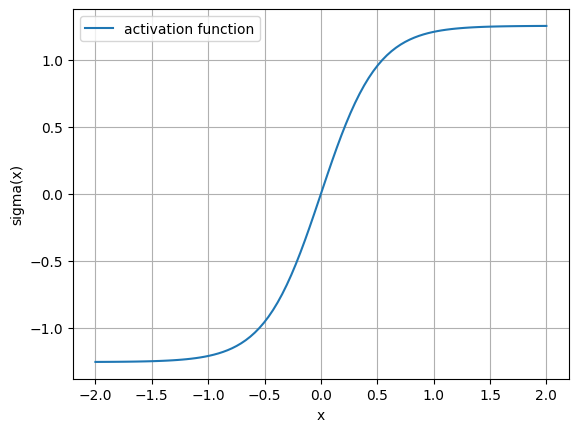

[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
0.9999999999999999
0.9992916877381335


In [6]:
# choose the activation function among the activations below
# the cell computes the first num_coeff Hermite coefficients and defines the function g()

analytical = False
activation = 'Tanh unitary'
num_coeff = 23

if (activation == 'ReLU' or activation == 'ReLU unitary'):
  analytic = True
else:
  analytic = False


if (analytic == True):
 if (activation == 'ReLU'):

      def sigma(x):
        return np.heaviside(x,1)*x

      def g_1(x):
        return -1/(2*np.pi) + x/4 + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_1_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2)))/(2*np.pi) + 1/4

      def g_3(x):
        return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_3_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi)

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

 if (activation == 'ReLU unitary'):

      var, error = scipy.integrate.quad(lambda x: (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
      #print(var)

      def sigma(x):
        return (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))/np.sqrt(var)

      def g_1(x):
        return (-1/(2*np.pi) + x/4 + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi))/var

      def g_1_prime(x):
        return ((np.arctan(x/np.sqrt(1-x**2)))/(2*np.pi) + 1/4)/var

      def g_3(x):
        return (-1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi))/var

      def g_3_prime(x):
        return ((np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi))/var

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

else:

  if (activation == 'ReLU unitary coeff'):

      var, error = scipy.integrate.quad(lambda x: (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
      #print(var)

      def sigma(x):
        return (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))/np.sqrt(var)

  elif (activation == 'Tanh'):
    def sigma(x):
        return np.tanh(2*x)

  elif (activation == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return np.tanh(2*x)/np.sqrt(var)   

  elif (activation == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var)       

  elif (activation == 'H3_tanh_wrapper_unitary'):
    def u1_np(x): return np.tanh(x)
    def u2_np(x): return np.tanh(3.0*x)   # change 3.0 to tune shape

    # compute projections under N(0,1)
    m1, _ = scipy.integrate.quad(lambda t: u1_np(t) * t * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)
    m2, _ = scipy.integrate.quad(lambda t: u2_np(t) * t * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)

    # coefficient to cancel H1 (linear) projection
    c = m1 / m2

    # un-normalized bounded function with H0=H1=H2=0
    def g_np(x):
      return u1_np(x) - c * u2_np(x)

    # normalize to unit variance under N(0,1)
    var_g, _ = scipy.integrate.quad(lambda t: (g_np(t)**2) * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)
    var_g = float(var_g)         

    def sigma(x):
      return g_np(x) / np.sqrt(var_g) 

  elif (activation == 'LeakyReLU'):
    def sigma(x):
        return np.heaviside(x,1)*x + 0.3*np.heaviside(-x,-1)*x

  elif (activation == 'ELU'):
    def sigma(x):
        return np.heaviside(x,1)*x + np.heaviside(-x,1)*(np.exp(x) - 1)

  elif (activation == 'Sigmoid'):
    def sigma(x):
        return 1/(1+np.exp(-x))

  elif (activation == 'Quadratic'):
    def sigma(x):
        return (x**2-1)/np.sqrt(2)

  elif (activation == 'Cubic'):
    def sigma(x):
        return (x**3 - 3*x)/np.sqrt(6)

  elif (activation == 'Quadratic + Cubic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Linear + Quadratic + Cubic'):
    def sigma(x):
        return x/np.sqrt(3) + (x**2 - 1)/2 + (x**3 - 3*x)/6

  elif (activation == 'Quadratic + Quartic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**4 - 6*x**2 + 3)/np.sqrt(4*3*2)

  elif (activation == 'Quartic'):
    def sigma(x):
        return (x**4 - 6*x**2 + 3)/np.sqrt(4*3*2)     

  elif (activation == 'Linear + Cubic'):
    def sigma(x):
        return (2*x + (x**3 - 3*x)/np.sqrt(6))/np.sqrt(2)     

  coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
  def g_1(x):
    g = 0
    for i in range(1,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_1_prime(x):
    g = 0
    for i in range(1,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

  def g_3(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_3_prime(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma(x), label='activation function')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients)
#print(f"{coefficients[1]:.30f}")
var_activ, error_activ = scipy.integrate.quad(lambda x: sigma(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
print(var_activ)
print(g_1(1))

In [7]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
num_v = 400  # Number of states
mult_sigma = 5  # Number of sigmas to consider
v_gauss, P_v_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo1 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo1 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo1 = 0*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo2 = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo2 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo2 = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo3 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo3 = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2  
q_W21_init_unfo3 = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_univ = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_univ = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_univ = 0.0*np.ones(v_gauss.shape[0]) # initial guess for q_W21

Delta = 0.2
Gamma_1 = 0.5
Gamma_2 = 0.5
d=200


# Range of alpha
Alpha_min = 0.01
Alpha_max = 8.5

init = Alpha_min
end = Alpha_max
num = 51

MMSE_NSB_FSB_info = []
q_W_1_NSB_FSB_info = []
q_W_2_NSB_FSB_info = []
q_W_12_NSB_FSB_info = []
q_W_1_NSB_FSB_info_mean = []
q_W_2_NSB_FSB_info_mean = []
q_W_12_NSB_FSB_info_mean = []
free_entropy_NSB_FSB_info = []
MMSE_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1 = []
q_W_2_NSB_FSB_unfo1 = []
q_W_12_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1_mean = []
q_W_2_NSB_FSB_unfo1_mean = []
q_W_12_NSB_FSB_unfo1_mean = []
free_entropy_NSB_FSB_unfo1 = []
MMSE_NSB_FSB_unfo2 = []
q_W_1_NSB_FSB_unfo2 = []
q_W_2_NSB_FSB_unfo2 = []
q_W_12_NSB_FSB_unfo2 = [] 
q_W_1_NSB_FSB_unfo2_mean = []
q_W_2_NSB_FSB_unfo2_mean = []
q_W_12_NSB_FSB_unfo2_mean = []
free_entropy_NSB_FSB_unfo2 = []
MMSE_NSB_FSB_unfo3 = []
q_W_1_NSB_FSB_unfo3 = []
q_W_2_NSB_FSB_unfo3 = []
q_W_12_NSB_FSB_unfo3 = [] 
q_W_1_NSB_FSB_unfo3_mean = []
q_W_2_NSB_FSB_unfo3_mean = []
q_W_12_NSB_FSB_unfo3_mean = []
free_entropy_NSB_FSB_unfo3 = []
q_W_1_NSB_FSB_univ = []
q_W_2_NSB_FSB_univ = []
q_W_12_NSB_FSB_univ = [] 
MMSE_NSB_FSB_univ = []
q_W_1_NSB_FSB_univ_mean = []
q_W_2_NSB_FSB_univ_mean = []
q_W_12_NSB_FSB_univ_mean = []
free_entropy_NSB_FSB_univ = []


for Alpha in np.linspace(init, end, num=num):
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_info,q_W2_init_info,q_W21_init_info,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_info.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_info.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_info.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_info.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_info_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_info_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_info_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_info.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo1,q_W2_init_unfo1,q_W21_init_unfo1,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo1.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo1.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo1.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo1_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo1_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo1.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo2,q_W2_init_unfo2,q_W21_init_unfo2,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo2.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo2.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo2.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo2_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo2_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo2.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo3,q_W2_init_unfo3,q_W21_init_unfo3,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo3.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo3.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo3.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo3.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo3_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo3_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo3_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo3.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_univ,q_W2_init_univ,q_W21_init_univ,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_univ.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_univ.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_univ.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_univ.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_univ_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_univ_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_univ_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_univ.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))

----------------------------------------------------------------
alpha = 0.01
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.17980000000000002
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.3496
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------

C:\Users\rudys\AppData\Local\Temp\ipykernel_63908\4246139860.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=small, loc='upper right')


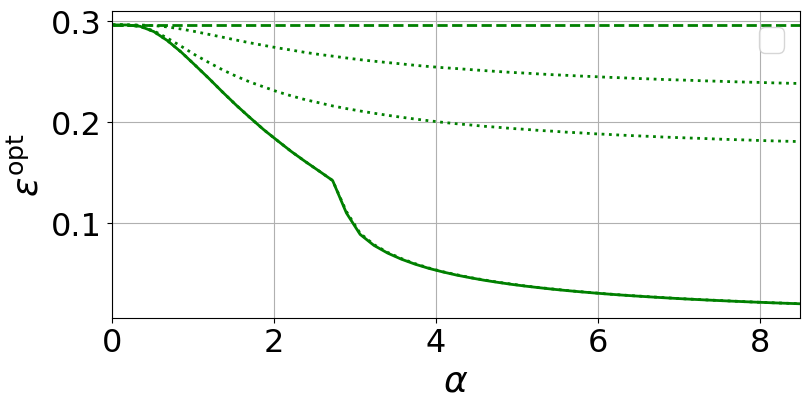

In [8]:
import sys,pandas as pd,matplotlib.pyplot as plt,numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib

width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_info, color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo1, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo2, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo3, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_univ, '--', color='green', linewidth=2.0)


ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=big)
ax.grid(True)

plt.tight_layout()
plt.legend(fontsize=small, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
plt.xlim(0,8.5)
plt.show()      

In [ ]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
num_v = 400  # Number of states
mult_sigma = 5  # Number of sigmas to consider
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
v_gauss, P_v_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21

q_W_1_NSB_FSB_plot = []
q_W_2_NSB_FSB_plot = []
q_W_12_NSB_FSB_plot = []
q_W_1_NSB_FS_plot = []
q_W_2_NSB_FS_plot = []
q_W_12_NSB_FS_plot = []
for a in [1.75, 2.75, 3.75]:
    print('alpha =',a)
    MMSE_NSB_xtra,q_W_1_NSB_xtra,q_W_2_NSB_xtra,q_W_12_NSB_xtra=mmse_qW_NSB_FSB_fast(q_W1_init_info,q_W2_init_info,q_W21_init_info,g_1,g_1_prime,g_3,g_3_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,d,coefficients,a,Gamma_1,Gamma_2,Delta)
    q_W_1_NSB_FSB_plot.append(q_W_1_NSB_xtra)
    q_W_2_NSB_FSB_plot.append(q_W_2_NSB_xtra)
    q_W_12_NSB_FSB_plot.append(q_W_12_NSB_xtra)

alpha = 1.75
alpha = 2.75
alpha = 3.75


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use LaTeX rendering for labels (requires LaTeX if text.usetex=True)
matplotlib.rcParams['text.usetex'] = True

width, height = 7, 5
big, small = int(width*3.3), int(width*2.7)

def _compute_edges(coords):
    """Given 1D coords of length N (cell centers), return edges length N+1."""
    coords = np.asarray(coords)
    if coords.size < 2:
        # fallback: arbitrary small edges
        return np.array([coords[0]-0.5, coords[0]+0.5])
    # midpoints between adjacent centers
    mid = 0.5 * (coords[:-1] + coords[1:])
    # first and last edges extrapolated
    first = coords[0] - (mid[0] - coords[0])
    last  = coords[-1] + (coords[-1] - mid[-1])
    edges = np.concatenate([[first], mid, [last]])
    return edges


def plot_combined(i,
                  q_W_2_NSB_FSB_plot,
                  q_W_1_NSB_FSB_plot,
                  q_W_12_NSB_FSB_plot,
                  v_gauss,
                  s2_gauss,
                  cmap='viridis',
                  figsize=(9,7),
                  main_ratio=4,    # relative size of main heatmap (height)
                  row_ratio=0.6,   # relative height for the small row heatmap under main
                  col_ratio=1.0,   # relative width for the left column
                  vmin=None,
                  vmax=None,
                  title=None,
                  fontsize=12):    # <--- new parameter to control font sizes
    """
    Combined figure:
      - main heatmap q_W_2_NSB_FSB_plot[i] with x=v_gauss and y=s2_gauss
      - a thin row heatmap under it: q_W_12_NSB_FSB_plot[i] (aligned to x)
      - a vertical column heatmap to the LEFT: q_W_1_NSB_FSB_plot[i] (aligned to y)
    """
    # --- fetch and validate data
    M = np.asarray(q_W_2_NSB_FSB_plot[i])
    v = np.asarray(v_gauss)
    s2 = np.asarray(s2_gauss)
    vec1 = np.asarray(q_W_1_NSB_FSB_plot[i])   # q_W_1 vs s2 (for the column)
    vec12 = np.asarray(q_W_12_NSB_FSB_plot[i]) # q_W_12 vs v (for the row)

    if M.ndim != 2:
        raise ValueError("q_W_2_NSB_FSB_plot[i] must be 2D.")

    nrows, ncols = M.shape

    # Align dims as in your previous function: ensure x matches cols and y matches rows (transpose if necessary)
    if v.size == ncols and s2.size == nrows:
        M_plot = M
    elif v.size == nrows and s2.size == ncols:
        M_plot = M.T
        nrows, ncols = M_plot.shape
    else:
        raise ValueError(f"Vector lengths must match matrix dimensions. Matrix shape {M.shape}, "
                         f"len(v_gauss)={v.size}, len(s2_gauss)={s2.size}.")

    # Validate 1D vectors match axes
    if vec12.size != ncols:
        raise ValueError(f"q_W_12 length {vec12.size} must match number of columns {ncols} (v axis).")
    if vec1.size != nrows:
        raise ValueError(f"q_W_1 length {vec1.size} must match number of rows {nrows} (s2 axis).")

    # compute edges
    x_edges = _compute_edges(v)
    y_edges = _compute_edges(s2)

    # compute shared color limits
    if vmin is None:
        # combine min across main, row and column
        vmin = np.nanmin([np.nanmin(M_plot), np.nanmin(vec12), np.nanmin(vec1)])
    if vmax is None:
        vmax = np.nanmax([np.nanmax(M_plot), np.nanmax(vec12), np.nanmax(vec1)])

    # --- layout with gridspec: 2 rows x 2 cols
    # Now: column on the LEFT (gs[:,0]) and main on the RIGHT (gs[:,1])
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(nrows=2, ncols=2,
                  height_ratios=[main_ratio, row_ratio],
                  width_ratios=[col_ratio, main_ratio],  # column is left now
                  hspace=0.05, wspace=0.05)

    # create left column axis first, then main and bottom row (which shares x with main)
    ax_col  = fig.add_subplot(gs[0,0])               # left column (vertical strip)
    ax_main = fig.add_subplot(gs[0,1], sharey=ax_col)  # main heatmap (to the right), share y with column
    ax_row  = fig.add_subplot(gs[1,1], sharex=ax_main) # thin row under main

    # --- main heatmap
    pcm_main = ax_main.pcolormesh(x_edges, y_edges, M_plot, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax_main.set_xlabel(r'$v$', fontsize=fontsize)
    # We'll place the y-label on the left column to avoid duplication
    if title is None:
        ax_main.set_title(r'$\mathcal{Q}^*_2(v,v^{(2)})$', fontsize=fontsize)
    else:
        ax_main.set_title(title, fontsize=fontsize)

    # set limits same as you used
    ax_main.set_xlim(-2, 2)
    ax_main.set_ylim(-2, 2)

    # Hide y tick labels on the main plot so the left column shows them instead (avoids duplication)
    plt.setp(ax_main.get_yticklabels(), visible=False)
    #ax_main.yaxis.set_ticks_position('right')
    #ax_main.yaxis.set_label_position('right')
    #ax_main.tick_params(axis='y', labelsize=fontsize, which='both', direction='out')


    # keep x tick labels hidden on the main (they appear on the bottom row)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # subtle separators (optional)
    for spine in ['top','left']:
        ax_main.spines[spine].set_visible(True)

    # --- row heatmap (thin horizontal strip under main)
    row_data = vec12.reshape(1, -1)   # 1 x ncols
    y_edges_row = np.array([0.0, 1.0])
    pcm_row = ax_row.pcolormesh(x_edges, y_edges_row, row_data, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # cosmetics for row
    ax_row.set_ylabel(r'$\mathcal{Q}^*_1(v^{(2)})$', fontsize=fontsize)
    ax_row.set_yticks([])  # no numeric ticks for this dummy vertical coord
    ax_row.set_xlabel(r'$v^{(2)}$', fontsize=fontsize)
    ax_row.set_xlim(ax_main.get_xlim())
    # x-tick labels visible here and sized
    plt.setp(ax_row.get_xticklabels(), visible=True)
    ax_row.tick_params(axis='x', labelsize=fontsize)

    # --- column heatmap (vertical strip on the left): use data shape (nrows,1)
    col_data = vec1.reshape(-1, 1)    # nrows x 1
    x_edges_col = np.array([0.0, 1.0])
    pcm_col = ax_col.pcolormesh(x_edges_col, y_edges, col_data, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # cosmetics for column: show y-axis numbers here (on the left)
    ax_col.set_xticks([])          # no x ticks for the narrow column
    ax_col.set_ylim(ax_main.get_ylim())
    ax_col.set_title(r'$\mathcal{Q}^*_{2:1}(v)$', fontsize=fontsize)
    # ensure y tick labels are visible and sized on the column
    ax_col.yaxis.set_tick_params(labelsize=fontsize)
    # put the y-label (for v^(2)) on the column so it's clear
    ax_col.set_ylabel(r'$v$', fontsize=fontsize)

    # ensure main's left spine is not overlapping the column
    ax_main.spines['left'].set_visible(False)
    ax_row.spines['left'].set_visible(False)
    ax_main.set_rasterized(True)
    ax_row.set_rasterized(True)
    ax_col.set_rasterized(True)
    custom_xyticks = [-2, -1, 0, 1, 2]   # tailor to your ε‐range
    ax_col.set_yticks(custom_xyticks)
    ax_row.set_xticks(custom_xyticks)

    ax_col.set_title(r'$\mathcal{Q}^*_{2:1}(v)$', fontsize=fontsize)
    ax_col.set_ylabel(r'$v$', fontsize=fontsize)
    ax_row.set_xlabel(r'$v^{(2)}$', fontsize=fontsize)
    ax_row.set_ylabel(r'$\mathcal{Q}^*_1(v^{(2)})$', fontsize=fontsize)
    ax_main.set_title(r'$\mathcal{Q}^*_2(v,v^{(2)})$', fontsize=fontsize)

    # shared colorbar (placed to the right of the main/rightmost part of the figure)
    cbar = fig.colorbar(pcm_main, ax=[ax_main, ax_row, ax_col], orientation='vertical', fraction=0.15, pad=0.012, aspect=14)
    cbar.ax.tick_params(labelsize=fontsize)
    custom_yticks_cbar = [0.2, 0.4, 0.6, 0.8]   # tailor to your ε‐range
    cbar.ax.set_yticks(custom_yticks_cbar)

    # overall figure title (larger by 4 than fontsize)
    fig.suptitle(r'$\alpha = 1.75$', fontsize=fontsize)
    fig.set_rasterized(True)

    # adjust layout and leave room for suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('3LNN_matrix_alpha_1.75.pdf', bbox_inches='tight')
    plt.show()
    return fig, (ax_main, ax_row, ax_col), (pcm_main, pcm_row, pcm_col)


C:\Users\rudys\AppData\Local\Temp\ipykernel_63908\1268894574.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


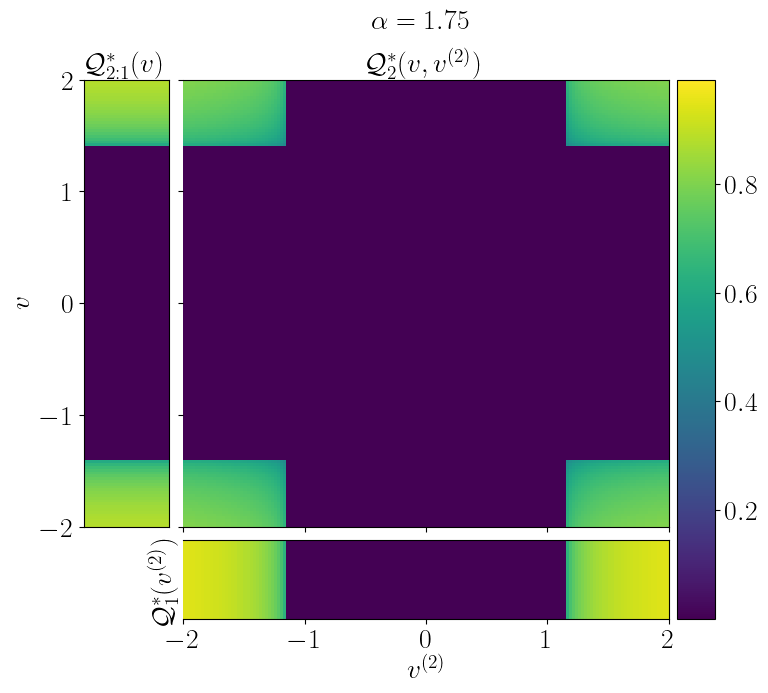

(<Figure size 900x700 with 4 Axes>,
 (<Axes: title={'center': '$\\mathcal{Q}^*_2(v,v^{(2)})$'}, xlabel='$v$'>,
  <Axes: xlabel='$v^{(2)}$', ylabel='$\\mathcal{Q}^*_1(v^{(2)})$'>,
  <Axes: title={'center': '$\\mathcal{Q}^*_{2:1}(v)$'}, ylabel='$v$'>),
 (<matplotlib.collections.QuadMesh at 0x29f3e223910>,
  <matplotlib.collections.QuadMesh at 0x29f551348b0>))

In [11]:
# ------------------------
# Example usage (keeps your naming)
i = 0
plot_combined(i, q_W_2_NSB_FSB_plot, q_W_12_NSB_FSB_plot, q_W_1_NSB_FSB_plot,
               s2_gauss, v_gauss,
               cmap='viridis', figsize=(9,7), main_ratio=4, row_ratio=0.7, col_ratio=0.7,
               fontsize=20)